In [2]:
import mne
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch, hilbert, detrend
import utils

In [ ]:
file = "data/sub-001_ses-04_block-001_task-ssvep_eeg.edf"
data = mne.io.read_raw_edf(file, preload=True)
raw_data = data.get_data()
# you can get the metadata included in the file and a list of all channels:
info = data.info
channels = data.ch_names
print(raw_data)
print("Sampling freq:", info['sfreq'])
print("Channels:", len(channels))

Extracting EDF parameters from c:\Users\danie_13ucdo4\OneDrive\Desktop\ITAM\Tesis\Prueba\timegan2.0\data\sub-001_ses-04_block-001_task-ssvep_eeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
[[-4.42511635e-06 -9.00282292e-06 -9.30800336e-06 ... -1.78530556e-05
  -1.63271534e-05 -1.38857099e-05]
 [ 2.28885328e-06  7.62951095e-07 -4.57770657e-07 ...  1.54116121e-05
   1.51064317e-05  1.38857099e-05]
 [-2.42618448e-05 -2.28885328e-06  1.63271534e-05 ... -4.42511635e-06
  -3.81475547e-06 -3.81475547e-06]
 ...
 [-4.16571298e-05 -4.04364080e-05 -3.89105058e-05 ...  1.67849241e-06
   1.67849241e-06  1.67849241e-06]
 [-3.55535210e-05 -3.40276188e-05 -3.21965362e-05 ...  3.50957504e-06
   2.89921416e-06  2.59403372e-06]
 [-2.73136492e-05 -2.60929274e-05 -2.39566644e-05 ...  1.35805295e-05
   1.26649882e-05  1.14442664e-05]]
Sampling freq: 1000.0
Channels: 64


In [ ]:
channels_tsv = "data/sub-001_ses-04_block-001_task-ssvep_electrodes.tsv"
events_tsv   = "data/sub-001_ses-04_block-001_task-ssvep_events.tsv"

df_channels = pd.read_csv(channels_tsv, sep="\t")
df_events = pd.read_csv(events_tsv, sep="\t")

df_channels

,name,x,y,z,impedance
0,FP1,-0.149789,0.311995,0.938202,NaN
1,FPZ,0.000323,0.321634,0.946864,NaN
2,FP2,0.150539,0.314406,0.937276,NaN
3,AF3,-0.224456,0.246970,0.942669,NaN
4,AF4,0.225207,0.250988,0.941428,NaN
...,...,...,...,...,...
59,CB1,-0.309324,-0.293760,0.904447,NaN
60,O1,-0.150018,-0.304209,0.940719,NaN
61,OZ,0.000323,-0.318418,0.947950,NaN
62,O2,0.147406,-0.304209,0.941131,NaN


In [5]:
df_events

,onset,duration,trial,value,stim_frequency
0,25454,5,1,218,32
1,33467,5,2,227,8
2,58750,5,3,235,40
3,66762,5,4,237,48
4,74774,5,5,222,48
5,82787,5,6,230,20
6,93616,5,7,221,44
7,101624,5,8,233,32
8,117649,5,9,214,16
9,142619,5,10,228,12


In [6]:
print(df_events[['onset', 'duration']].head())
print("Recording length (s):", data.times[-1])


   onset  duration
0  25454         5
1  33467         5
2  58750         5
3  66762         5
4  74774         5
Recording length (s): 525.999


In [7]:
raw_data.shape

(64, 526000)

In [8]:
# channels you want to inspect (pairs expanded)
channel_groups = [
    ['PZ'],
    ['PO3', 'PO4'],
    ['PO5', 'PO6'],
    ['POZ'],
    ['OZ'],
    ['O1', 'O2']
]

In [9]:
wanted_channels = []
for group in channel_groups:
    for ch in group:
        if ch in data.ch_names:
            wanted_channels.append(ch)

print("Channels to plot:", wanted_channels)

Channels to plot: ['PZ', 'PO3', 'PO4', 'PO5', 'PO6', 'POZ', 'OZ', 'O1', 'O2']


In [10]:
n_samples = 5000
filtered_data = data.get_data(picks=wanted_channels)[:, :n_samples]

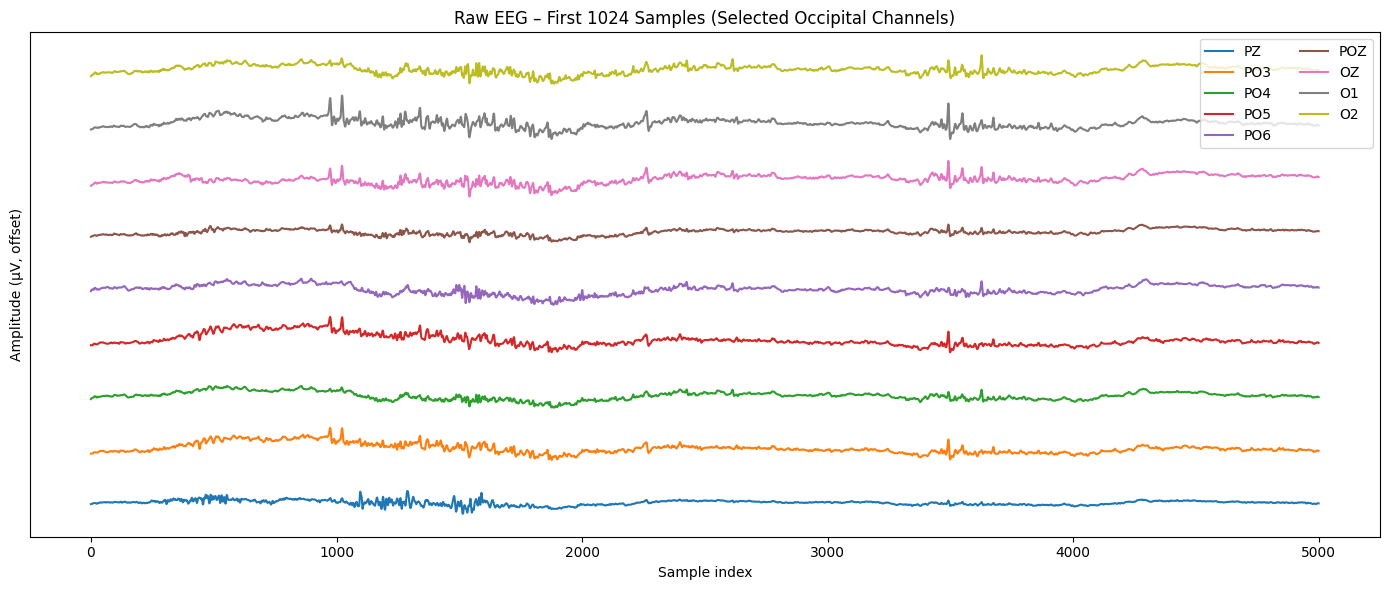

In [11]:
plt.figure(figsize=(14, 6))

offset = 0
spacing = np.max(np.abs(filtered_data)) * 2  # adaptive spacing

for i, ch in enumerate(wanted_channels):
    plt.plot(filtered_data[i] + offset, label=ch)
    offset += spacing

plt.title("Raw EEG – First 1024 Samples (Selected Occipital Channels)")
plt.xlabel("Sample index")
plt.ylabel("Amplitude (µV, offset)")
plt.yticks([])  # offsets make absolute y meaningless
plt.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()


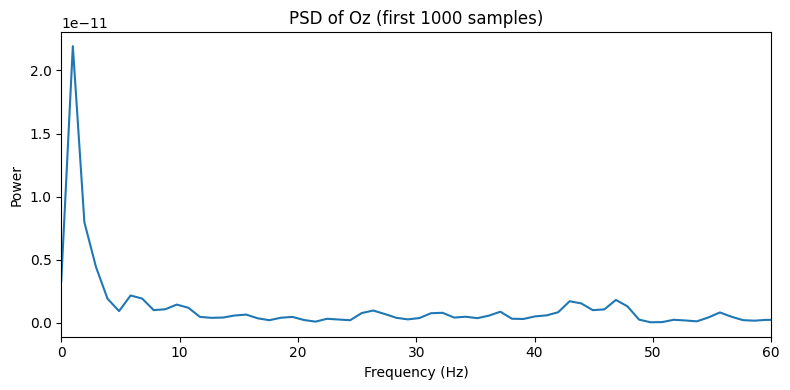

In [12]:
from scipy.signal import welch

ch = wanted_channels.index('Oz') if 'Oz' in wanted_channels else 0
f, p = welch(filtered_data[ch], fs=1000, nperseg=1024)

plt.figure(figsize=(8,4))
plt.plot(f, p)
plt.xlim(0, 60)
plt.title("PSD of Oz (first 1000 samples)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.tight_layout()
plt.show()


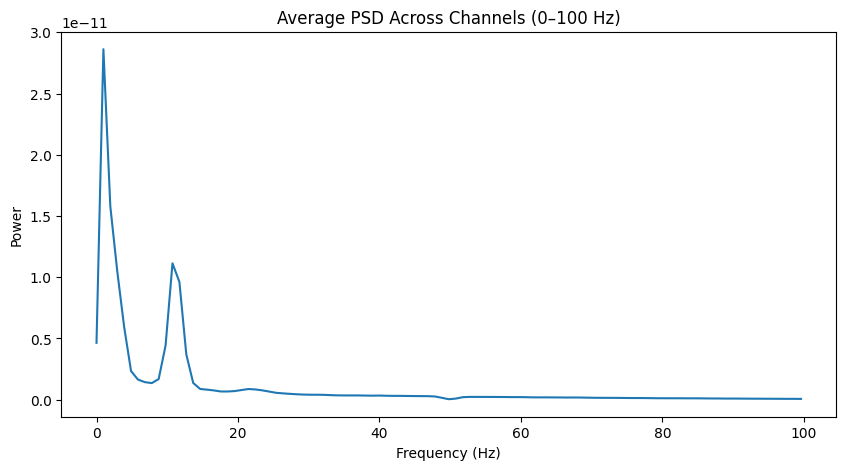

Max PSD value: 2.504251596990532e-10


In [13]:
fs = info['sfreq']

def compute_psd(data, fs, max_freq=100):
    freqs, psd = welch(data, fs=fs, nperseg=1024)
    mask = freqs <= max_freq
    return freqs[mask], psd[:, mask]

freqs, psds = compute_psd(raw_data, fs)

plt.figure(figsize=(10,5))
plt.plot(freqs, np.mean(psds, axis=0))
plt.title("Average PSD Across Channels (0–100 Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.show()

print("Max PSD value:", np.max(psds))

In [14]:
annotations = data.annotations
events, event_id = mne.events_from_annotations(data)

event_id

Used Annotations descriptions: ['211', '212', '213', '214', '215', '216', '217', '218', '219', '220', '221', '222', '223', '224', '225', '226', '227', '228', '229', '230', '231', '232', '233', '234', '235', '236', '237', '238', '239', '240']


{'211': 1,
 '212': 2,
 '213': 3,
 '214': 4,
 '215': 5,
 '216': 6,
 '217': 7,
 '218': 8,
 '219': 9,
 '220': 10,
 '221': 11,
 '222': 12,
 '223': 13,
 '224': 14,
 '225': 15,
 '226': 16,
 '227': 17,
 '228': 18,
 '229': 19,
 '230': 20,
 '231': 21,
 '232': 22,
 '233': 23,
 '234': 24,
 '235': 25,
 '236': 26,
 '237': 27,
 '238': 28,
 '239': 29,
 '240': 30}

In [15]:
tmin, tmax = 0, 5   # 5-second epochs (modify if needed)

epochs = mne.Epochs(data, events, event_id=event_id,
                    tmin=tmin, tmax=tmax,
                    baseline=None, preload=True)

epochs

Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Loading data for 30 events and 5001 original time points ...
0 bad epochs dropped


<Epochs | 30 events (all good), 0 – 5 s (baseline off), ~73.3 MB, data loaded,
 '211': 1
 '212': 1
 '213': 1
 '214': 1
 '215': 1
 '216': 1
 '217': 1
 '218': 1
 '219': 1
 '220': 1
 and 20 more events ...>

In [16]:
X = epochs.get_data()     # shape (n_epochs, n_channels, n_samples)
event_vals = df_events['value'].values 

In [17]:
idx_high = [i for i, v in enumerate(event_vals) if v % 2 == 0]
X_high = X[idx_high]

In [18]:
X_high.shape

(15, 64, 5001)

In [19]:
sfreq = int(data.info['sfreq'])

onset_sample = 142619
duration_sec = 5
duration_samples = duration_sec * sfreq

start = onset_sample
end   = onset_sample + duration_samples

raw_12hz = data.copy().crop(
    tmin=start / sfreq,
    tmax=end   / sfreq
)


In [20]:
raw_12hz

<RawEDF | sub-001_ses-04_block-001_task-ssvep_eeg.edf, 64 x 5001 (5.0 s), ~53 kB, data not loaded>

In [21]:
n_samples = 5000
filtered_data = raw_12hz.get_data(picks=wanted_channels)[:, :n_samples]

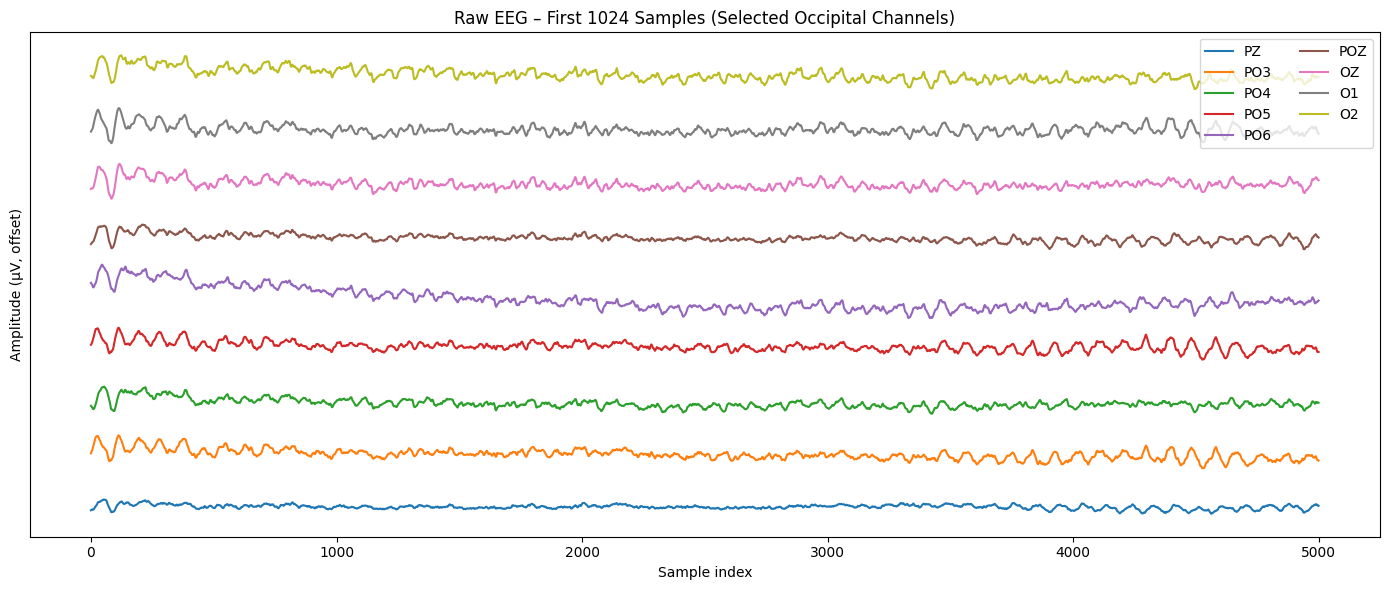

In [22]:
plt.figure(figsize=(14, 6))

offset = 0
spacing = np.max(np.abs(filtered_data)) * 2  # adaptive spacing

for i, ch in enumerate(wanted_channels):
    plt.plot(filtered_data[i] + offset, label=ch)
    offset += spacing

plt.title("Raw EEG – First 1024 Samples (Selected Occipital Channels)")
plt.xlabel("Sample index")
plt.ylabel("Amplitude (µV, offset)")
plt.yticks([])  # offsets make absolute y meaningless
plt.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()


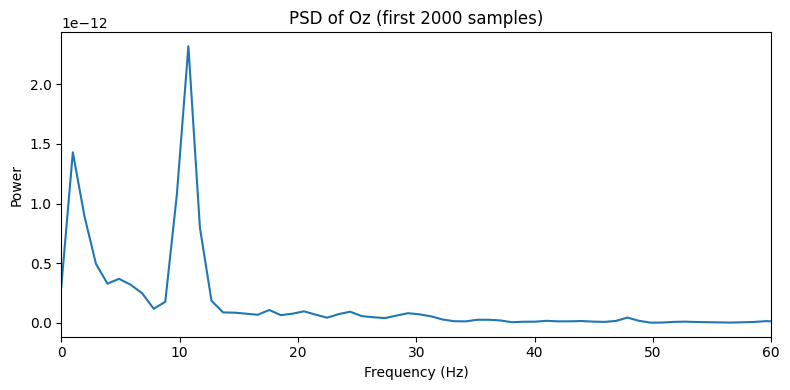

In [23]:
from scipy.signal import welch

ch = wanted_channels.index('Oz') if 'Oz' in wanted_channels else 0
f, p = welch(filtered_data[ch], fs=1000, nperseg=1024)

plt.figure(figsize=(8,4))
plt.plot(f, p)
plt.xlim(0, 60)
plt.title("PSD of Oz (first 2000 samples)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.tight_layout()
plt.show()

In [27]:
raw_12hz_filt = raw_12hz.copy().filter(
    l_freq=10,
    h_freq=14,
    method='fir',
    phase='zero'
)

RuntimeError: By default, MNE does not load data into main memory to conserve resources. inst.filter requires raw data to be loaded. Use preload=True (or string) in the constructor or raw.load_data().

In [ ]:
n_samples = 2000
filtered_data = raw_12hz_filt.get_data(picks=wanted_channels)[:, :n_samples]

In [ ]:
plt.figure(figsize=(14, 6))

offset = 0
spacing = np.max(np.abs(filtered_data)) * 2  # adaptive spacing

for i, ch in enumerate(wanted_channels):
    plt.plot(filtered_data[i] + offset, label=ch)
    offset += spacing

plt.title("Raw EEG – First 1024 Samples (Selected Occipital Channels)")
plt.xlabel("Sample index")
plt.ylabel("Amplitude (µV, offset)")
plt.yticks([])  # offsets make absolute y meaningless
plt.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()
